SUMMARY: Results from 128x128 patch size clustering

In [ ]:
import pandas as pd
df = pd.read_parquet("normalised_run_128.parquet")s

print(df.head())
print(df.shape)

                                               image  \
0  /data/test_images/2022_02_02 5nm Ag nanopartic...   
1  /data/test_images/2022_02_02 5nm Ag nanopartic...   
2  /data/test_images/2022_02_02 5nm Ag nanopartic...   
3  /data/test_images/2022_02_02 5nm Ag nanopartic...   
4  /data/test_images/2022_02_02 5nm Ag nanopartic...   

                                    clustered_labels  \
0  [6, 6, 6, 0, 7, 0, 0, 0, 6, 6, 6, 6, 6, 6, 6, ...   
1  [4, 0, 0, 0, 6, 0, 3, 1, 6, 6, 4, 4, 4, 4, 4, ...   
2  [0, 1, 7, 1, 1, 7, 1, 7, 7, 4, 0, 0, 0, 0, 0, ...   
3  [3, 6, 3, 0, 7, 2, 2, 7, 5, 6, 3, 3, 3, 3, 3, ...   
4  [3, 5, 5, 5, 0, 0, 0, 0, 0, 6, 2, 2, 2, 2, 2, ...   

                                           positions  \
0  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
1  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
2  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
3  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
4  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64]

In [2]:
import glob
import os
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.cluster import KMeans
from skimage.util import view_as_windows
import numpy as np
from persim import PersistenceImager
from ripser import lower_star_img
import pandas as pd
from itertools import islice

def get_positions(image_data, patch_size=128, stride=16):
    if stride is None:
        stride = patch_size

    blocks = view_as_windows(
        image_data,
        (patch_size, patch_size),
        step=stride
    )

    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * stride, j * stride)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions


def label_to_image_vote(labels, positions, image, patch_size):

    H, W = image.shape

    n_labels = len(np.unique(labels))

    votes = np.zeros(
        (H,W,n_labels),
        dtype=np.uint16
    )

    for (r,c), lab in zip(positions, labels):

        votes[
            r:r+patch_size,
            c:c+patch_size,
            lab
        ] += 1

    label_img = np.argmax(votes, axis=2)

    return label_img

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


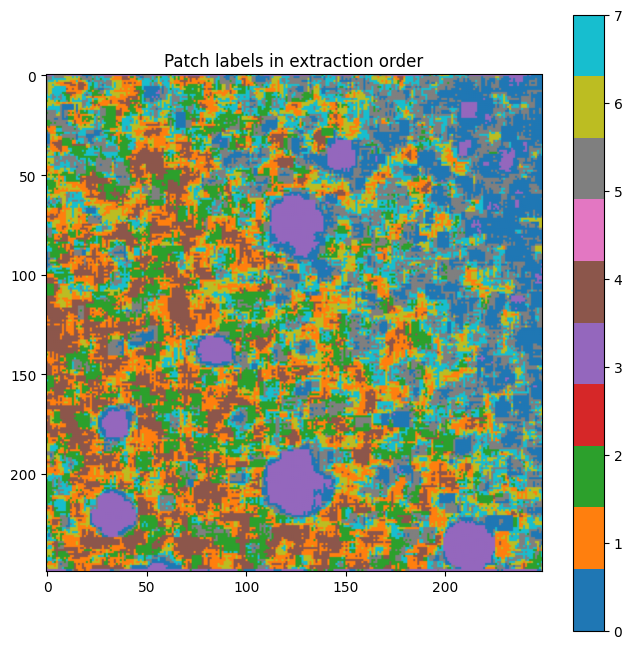

Image size: (4096, 4096)
Last patch start: (3968, 3968)
Last patch end: (4096, 4096)


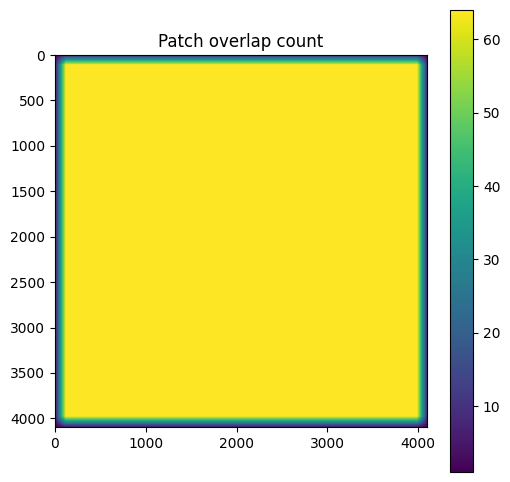

In [22]:


image_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/")
labels_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels")

output = Path("./cluster_results")


for id, row in df.iterrows():

    image_name = Path(row["image"]).stem
    out_dir = output / image_name
    out_dir.mkdir(parents=True, exist_ok=True)  

    matches = list(image_dir.glob(f"{image_name}.dm3"))
    truths = list(labels_dir.glob(f"{image_name}_label.png"))
    labels = row["clustered_labels"]

    if not matches:
        continue

    image_path = matches[0]
    truth_path = truths[0]
    data_dict = dm.dmReader(str(Path(image_path).resolve()))
    original_image = data_dict['data']
    positions = get_positions(
    original_image,
    patch_size=128,
    stride=16
)

def label_to_image_simple(original_image, labels, positions, patch_size):

    H, W = original_image.shape[:2]

    label_img = np.zeros((H,W), dtype=np.uint8)

    for (r,c), lab in zip(positions, labels):

        label_img[
            r:r+patch_size,
            c:c+patch_size
        ] = lab

    return label_img

label_img = label_to_image_simple(
    original_image,
    labels,
    positions,
    128
)

label_grid = np.array(labels).reshape(249, 249)

plt.figure(figsize=(8,8))
plt.imshow(label_grid, cmap="tab10")
plt.title("Patch labels in extraction order")
plt.colorbar()
plt.show()

H, W = original_image.shape[:2]

max_r = max(r for r,c in positions)
max_c = max(c for r,c in positions)

print("Image size:", (H,W))
print("Last patch start:", (max_r,max_c))
print("Last patch end:", (max_r+128, max_c+128))

coverage = np.zeros_like(original_image)

for r,c in positions:
    coverage[
        r:r+128,
        c:c+128
    ] += 1

plt.figure(figsize=(6,6))
plt.imshow(coverage)
plt.colorbar()
plt.title("Patch overlap count")
plt.show()

In [34]:
import numpy as np
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk
from pathlib import Path

image_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/")
labels_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels")

output = Path("./cluster_results")


for id, row in df.iterrows():

    image_name = Path(row["image"]).stem
    out_dir = output / image_name
    out_dir.mkdir(parents=True, exist_ok=True)  

    matches = list(image_dir.glob(f"{image_name}.dm3"))
    truths = list(labels_dir.glob(f"{image_name}_label.png"))

    if not matches:
        continue

    image_path = matches[0]
    truth_path = truths[0]
    data_dict = dm.dmReader(str(Path(image_path).resolve()))
    original_image = data_dict['data']
    truth_img = mpimg.imread(truth_path).astype(np.uint8)

    labels = row["clustered_labels"]
    positions = get_positions(original_image, 128, 16)
    label_img = label_to_image_vote(row["clustered_labels"], positions, original_image, 128)
    output_path = out_dir / "labelimg.png"

    plt.imsave(output_path, label_img, cmap="tab20")

    clusters =[0,1,2,3,4,5,6,7]

    for i in clusters:

        pred_mask  = (label_img == i)        
        truth_mask = (truth_img > 0)  

        clean_mask = remove_small_objects(pred_mask, max_size=100)
        clean_mask = binary_fill_holes(clean_mask)
        clean_mask = binary_closing(clean_mask, footprint=disk(2))
        clean_mask = remove_small_objects(clean_mask, max_size=1600)

        intersection = (clean_mask & truth_mask).sum()
        union        = (clean_mask | truth_mask).sum()

        iou  = intersection / union                              

        print(f"Image {str(image_name)} Cluster {i} — IoU: {iou:.3f} ")
        accuracy = np.mean(clean_mask == truth_mask) * 100
        print(f"Accuracy: {accuracy:.2f}%")
        plt.imsave(out_dir / f"cluster_{i}_raw.png", pred_mask, cmap="tab20")
        plt.imsave(out_dir / f"cluster_{i}.png", clean_mask, cmap="tab20")

/tmp/ipykernel_26306/150849763.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 0 — IoU: 0.014 
Accuracy: 81.40%


/tmp/ipykernel_26306/150849763.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_08 Cluster 1 — IoU: 0.000 
Accuracy: 80.08%


/tmp/ipykernel_26306/150849763.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


...

Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 5 — IoU: 0.015 
Accuracy: 78.87%


/tmp/ipykernel_26306/150849763.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 6 — IoU: 0.001 
Accuracy: 88.06%


/tmp/ipykernel_26306/150849763.py:47: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean_mask = binary_closing(clean_mask, footprint=disk(2))


Image 20220202_Ag_UTC_330kx_2650e_0p1596s_11 Cluster 7 — IoU: 0.002 
Accuracy: 86.67%


In [53]:
import itertools
from skimage.morphology import closing
image_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/")
labels_dir = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels")

output = Path("./cluster_results")


for id, row in df.iterrows():

    image_name = Path(row["image"]).stem
    out_dir = output / image_name
    out_dir.mkdir(parents=True, exist_ok=True)  

    matches = list(image_dir.glob(f"{image_name}.dm3"))
    truths = list(labels_dir.glob(f"{image_name}_label.png"))

    if not matches:
        continue

    image_path = matches[0]
    truth_path = truths[0]
    data_dict = dm.dmReader(str(Path(image_path).resolve()))
    original_image = data_dict['data']
    truth_img = mpimg.imread(truth_path).astype(np.uint8)

    labels = row["clustered_labels"]
    positions = get_positions(original_image, 128, 16)
    label_img = label_to_image_vote(row["clustered_labels"], positions, original_image, 128)
    clusters = sorted(np.unique(label_img))

    best_iou=-1
    best_combo = None
    best_mask = None

    truth_mask = truth_img > 0

    selected = []
    best_iou = 0

    remaining = list(np.unique(label_img))

    while remaining:

        improvements = []

        for c in remaining:
            combo = selected + [c]

            pred = np.isin(label_img, combo)

            clean = remove_small_objects(pred, max_size=100)
            clean = binary_fill_holes(clean)
            clean = closing(clean, footprint=disk(2))
            clean = remove_small_objects(clean, max_size=1600)

            inter = np.logical_and(clean, truth_mask).sum()
            union = np.logical_or(clean, truth_mask).sum()

            iou = inter / union

            improvements.append((iou, c))

        improvements.sort(reverse=True)

        new_iou, best_cluster = improvements[0]

        if new_iou > best_iou:
            selected.append(best_cluster)
            remaining.remove(best_cluster)
            best_iou = new_iou

            print(
                f"Added cluster {best_cluster}, "
                f"IoU={best_iou:.3f}"
            )

        else:
            break

    print(f"{image_name}")
    print(f"Best cluster combination: {best_combo}")
    print(f"Best IoU: {best_iou:.3f}")




Added cluster 6, IoU=0.336
20220202_Ag_UTC_330kx_2650e_0p1596s_08
Best cluster combination: None
Best IoU: 0.336
Added cluster 4, IoU=0.357
20220202_Ag_UTC_330kx_2650e_0p1596s_05
Best cluster combination: None
Best IoU: 0.357
Added cluster 0, IoU=0.330
20220202_Ag_UTC_330kx_2650e_0p1596s_07
Best cluster combination: None
Best IoU: 0.330
Added cluster 3, IoU=0.349
Added cluster 6, IoU=0.564
20220202_Ag_UTC_330kx_2650e_0p1596s_03
Best cluster combination: None
Best IoU: 0.564
Added cluster 2, IoU=0.349
Added cluster 3, IoU=0.557
20220202_Ag_UTC_330kx_2650e_0p1596s_02
Best cluster combination: None
Best IoU: 0.557
Added cluster 7, IoU=0.508
20220202_Ag_UTC_330kx_2650e_0p1596s_10
Best cluster combination: None
Best IoU: 0.508
Added cluster 5, IoU=0.483
Added cluster 0, IoU=0.500
20220202_Ag_UTC_330kx_2650e_0p1596s_13
Best cluster combination: None
Best IoU: 0.500
Added cluster 2, IoU=0.489
Added cluster 6, IoU=0.662
20220202_Ag_UTC_330kx_2650e_0p1596s_12
Best cluster combination: None
Best

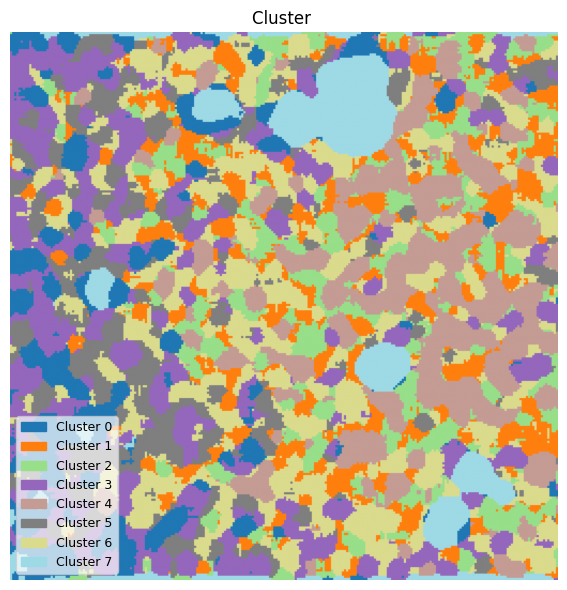

In [28]:
image_name = "20220202_Ag_UTC_330kx_2650e_0p1596s_10"

row = df[df["image"].apply(lambda x: Path(x).stem == image_name)]

if row.empty:
    print(f"{image_name} not found in DataFrame")
else:
    row = row.iloc[0]

    image_path = image_dir / f"{image_name}.dm3"
    truth_path = labels_dir / f"{image_name}_label.png"

    data_dict = dm.dmReader(str(image_path.resolve()))
    original_image = data_dict["data"]
    truth_img = mpimg.imread(truth_path).astype(np.uint8)

    positions = get_positions(original_image, 128, 16)
    label_img = label_to_image_vote(
        row["clustered_labels"],
        positions,
        original_image,
        128,
    )

    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.patches as mpatches

    plt.figure(figsize=(6,6))

    clusters = np.unique(label_img)
    cmap = plt.get_cmap("tab20", len(clusters))

    plt.imshow(label_img, cmap=cmap)

    plt.title("Cluster ")
    plt.axis("off")

    legend_patches = [
        mpatches.Patch(color=cmap(i), label=f"Cluster {c}")
        for i, c in enumerate(clusters)
    ]

    plt.legend(
        handles=legend_patches,
        loc="lower left",          # inside plot
        frameon=True,             # box around legend
        framealpha=0.7,           # semi-transparent
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

0.508435177577059


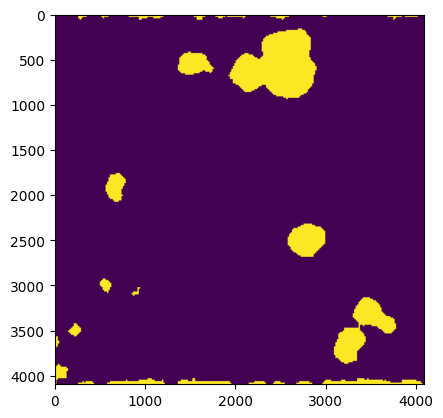

In [29]:

import numpy as np
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import closing, disk
from pathlib import Path


combo = (7)

pred = np.isin(label_img, combo)

clean = remove_small_objects(pred, max_size=100)
clean = binary_fill_holes(clean)
clean = closing(clean, footprint=disk(2))
clean = remove_small_objects(clean, max_size=1600)
truth_mask = truth_img > 0
inter = np.logical_and(clean, truth_mask).sum()
union = np.logical_or(clean, truth_mask).sum()

iou = inter / union
print(iou)
plt.imshow(clean)

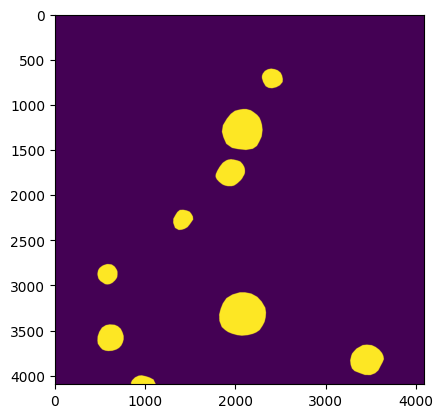

In [30]:
plt.imshow(truth_mask)

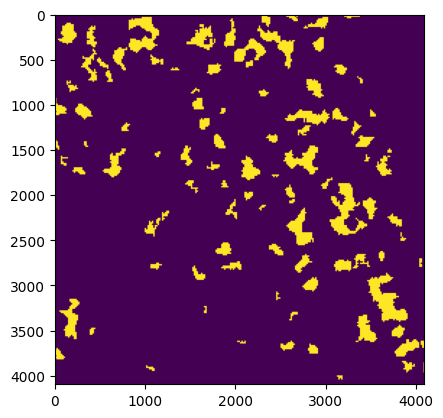

In [31]:
plt.imshow(clean_mask)

In [42]:
import numpy as np
import json
import ast
from ripser import lower_star_img

def reconstruct_single_image(df, row_index=0, patch_size=64):
    """
    Reconstructs the crystallinity map for a single image row using 
    unsupervised TDA weights on its nested 'densities' grids.
    """
    row = df.iloc[row_index]
    image_name = row['image']
    
    # 1. Safely parse 'positions' to a true 2D numpy array
    raw_positions = row['positions']
    if isinstance(raw_positions, str):
        try:
            raw_positions = json.loads(raw_positions)
        except Exception:
            raw_positions = ast.literal_eval(raw_positions)
    
    positions = np.vstack(raw_positions)  # Forces shape to (N, 2)
    
    # 2. Safely parse 'densities' from string to a Python dictionary
    densities_dict = row['densities'] 
    if isinstance(densities_dict, str):
        try:
            densities_dict = json.loads(densities_dict)
        except Exception:
            densities_dict = ast.literal_eval(densities_dict)
    
    print(f"Processing Image: {image_name}")
    print(f"Total patches to process: {len(positions)}")
    
    # Calculate global canvas boundaries
    max_y = int(np.max(positions[:, 0]) + patch_size)
    max_x = int(np.max(positions[:, 1]) + patch_size)
    
    weight_canvas = np.zeros((max_y, max_x), dtype=np.float32)
    vote_canvas = np.zeros((max_y, max_x), dtype=np.float32)
    
    # List to store computed raw topological lifetimes
    patch_weights = []
    
    # --- Pass 1: Compute Topological Persistence of each Density Grid ---
    for idx, (y, x) in enumerate(positions):
        # Handle string ('0') vs integer (0) keys in the parsed dictionary
        key = str(idx) if str(idx) in densities_dict else idx
        
        # Extract the density grid
        density_grid = np.array(densities_dict[key]['density_grid'])
        
        # Invert grid so density peaks generate early births in lower-star filtration
        inverted_grid = np.max(density_grid) - density_grid
        
        # Calculate lower-star persistent homology
        dgms = lower_star_img(inverted_grid)
        
        if len(dgms) >= 2 and len(dgms[1]) > 0:
            # FIX: Ensure h1_points is ALWAYS 2D (shape: N x 2), even if N=1
            h1_points = np.atleast_2d(dgms[1])
            
            births = h1_points[:, 0]
            deaths = h1_points[:, 1]
            
            # Filter out infinite/essential features
            finite_mask = np.isfinite(deaths)
            lifetimes = deaths[finite_mask] - births[finite_mask]
            raw_persistence = np.sum(lifetimes)
        else:
            raw_persistence = 0.0
            
        patch_weights.append((y, x, raw_persistence))
    
    # --- Pass 2: Normalize Weights and Aggregate Votes ---
    raw_lifetimes = [pw[2] for pw in patch_weights]
    min_lt = min(raw_lifetimes)
    max_lt = max(raw_lifetimes)
    
    for y, x, raw_lt in patch_weights:
        # Scale to [0, 1] range based on this specific image's lifetime profile
        norm_weight = (raw_lt - min_lt) / (max_lt - min_lt + 1e-7)
        
        # Cast votes across the patch footprint
        y, x = int(y), int(x)
        weight_canvas[y:y+patch_size, x:x+patch_size] += norm_weight
        vote_canvas[y:y+patch_size, x:x+patch_size] += 1.0
        
    # Generate final continuous map (average vote per pixel)
    final_likeness_map = weight_canvas / (vote_canvas + 1e-7)
    
    return final_likeness_map, image_name

In [43]:
# Reconstruct the image
likeness_map, img_title = reconstruct_single_image(df, row_index=1)

# Plotting the continuous TDA Likeness Map
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot continuous likeness
im1 = axes[0].imshow(likeness_map, cmap='inferno')
axes[0].set_title(f"Unsupervised Crystallinity Likeness\n{img_title.split('/')[-1]}")
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label="Crystallinity Metric")

# Plot binary mask
threshold = 0.5  # Adjust this dynamically to maximize your ground-truth IoU
binary_mask = likeness_map > threshold
axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title(f"Binary Segmentation Mask\n(Threshold: {threshold})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Processing Image: /data/test_images/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_05.dm3
Total patches to process: 62001


KeyError: 8